Dataset: https://www.kaggle.com/datasets/sonalshinde123/student-academic-performance-dataset

**About Dataset**

The dataset enables the prediction and analysis of Final Exam Marks based on several academic indicators. It can be used to build models that help understand which factors contribute most to student performance.

This dataset contains 2000 student academic records, including attendance, internal exam scores, assignment performance, daily study habits, and final exam marks.

It is suitable for:

Regression tasks
Exploratory data analysis (EDA)
Feature importance studies
Education analytics models
ML tutorials and demonstrations

In [2]:
# installing the dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn joblib xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

from joblib import dump



**Load dataset**

In [4]:
df = pd.read_csv('D:\My Learning\ML projects\Student-performance-prediction\dataset\Final_Marks_Data.csv')

In [5]:
df.head()

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [6]:
RANDOM_STATE = 42
df.shape

(2000, 7)

In [7]:
# missing values - analysis
df.isnull().sum()

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64

In [8]:
# identify the presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts())

Student_ID
S1000    1
S1001    1
S1002    1
S1003    1
S1004    1
        ..
S2995    1
S2996    1
S2997    1
S2998    1
S2999    1
Name: count, Length: 2000, dtype: int64
Attendance (%)
86     119
84     103
85     100
87      95
82      95
83      90
81      88
88      87
80      84
91      80
90      80
89      79
78      76
100     74
79      73
77      72
94      61
93      59
92      58
76      50
75      40
95      38
74      38
97      33
72      32
96      31
98      28
73      27
71      24
99      24
70      17
69      13
68      10
67       5
66       4
65       3
60       3
62       3
63       2
52       1
58       1
Name: count, dtype: int64
Internal Test 1 (out of 40)
32    173
33    169
30    162
34    155
31    146
29    136
35    127
40    126
36    120
37    119
28    117
27     92
38     70
39     64
26     63
25     62
23     29
24     27
21     17
22     13
20      5
18      4
19      4
Name: count, dtype: int64
Internal Test 2 (out of 40)
35    171
33    168
31  

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop(columns=["Student_ID"])

Student_ID	Attendance (%)	Internal Test 1 (out of 40)	Internal Test 2 (out of 40)	Assignment Score (out of 10)	Daily Study Hours	Final Exam Marks (out of 100)

In [11]:
#Rename All Columns At Once
df.columns =  ["Attendance", "Test1", "Test2", "Assignment", "StudyHrs", "FinalExamMarks"]
target_column = 'FinalExamMarks'

In [12]:
# identify duplicate rows
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated row:\n",df[duplicate_mask])

Number of duplicate rows: 3
Duplicated row:
       Attendance  Test1  Test2  Assignment  StudyHrs  FinalExamMarks
878           94     36     35           8         2              68
1055          82     35     29           7         3              66
1825          84     30     36           7         3              66


In [13]:
df = df.drop_duplicates()
df.shape

(1997, 6)

In [14]:
# Check constant columns
df.nunique()

Attendance        41
Test1             23
Test2             23
Assignment         7
StudyHrs           5
FinalExamMarks    66
dtype: int64

In [15]:
df.dtypes

Attendance        int64
Test1             int64
Test2             int64
Assignment        int64
StudyHrs          int64
FinalExamMarks    int64
dtype: object

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Attendance      1997 non-null   int64
 1   Test1           1997 non-null   int64
 2   Test2           1997 non-null   int64
 3   Assignment      1997 non-null   int64
 4   StudyHrs        1997 non-null   int64
 5   FinalExamMarks  1997 non-null   int64
dtypes: int64(6)
memory usage: 109.2 KB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Attendance,1997.0,84.888833,7.761710,52.0,80.0,85.0,90.0,100.0
Test1,1997.0,32.113170,4.565402,18.0,29.0,32.0,35.0,40.0
Test2,1997.0,32.463195,4.524513,16.0,29.0,33.0,36.0,40.0
Assignment,1997.0,7.507261,1.021597,4.0,7.0,8.0,8.0,10.0
StudyHrs,1997.0,2.823736,0.608867,1.0,2.0,3.0,3.0,5.0
FinalExamMarks,1997.0,64.852278,11.349508,25.0,58.0,65.0,73.0,100.0


**Data Visualization**

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns

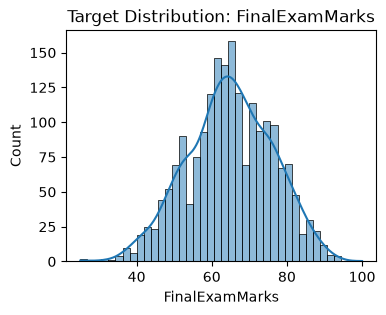

In [19]:
# target column distribution
plt.figure(figsize=(4,3))
sns.histplot(df[target_column], bins=40, kde=True)
plt.title(f"Target Distribution: {target_column}")
plt.xlabel(target_column)
plt.show()

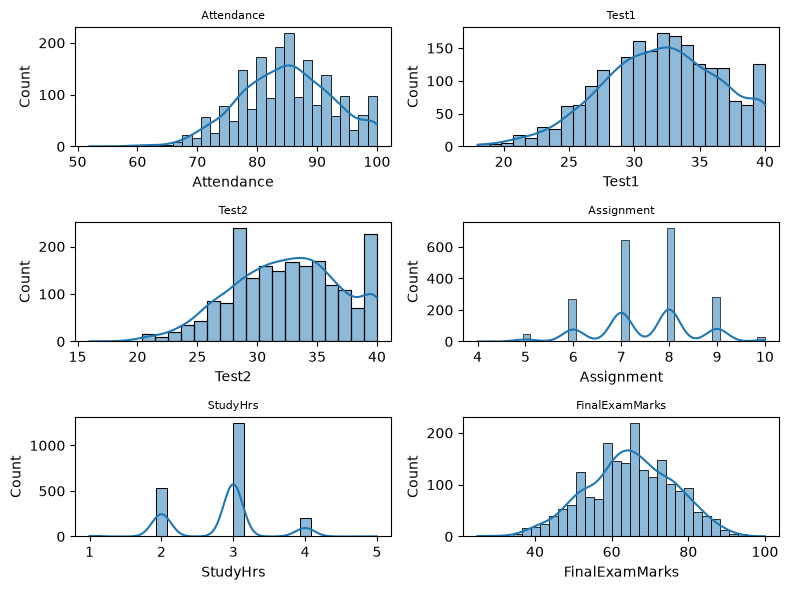

In [20]:
# histogram plot - distribution
fig, axes = plt.subplots(3, 2, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

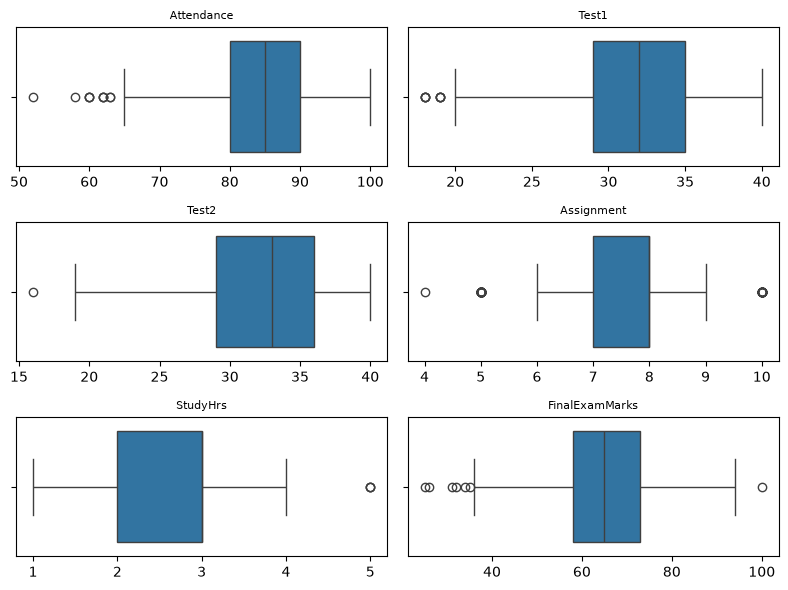

In [21]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 2, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

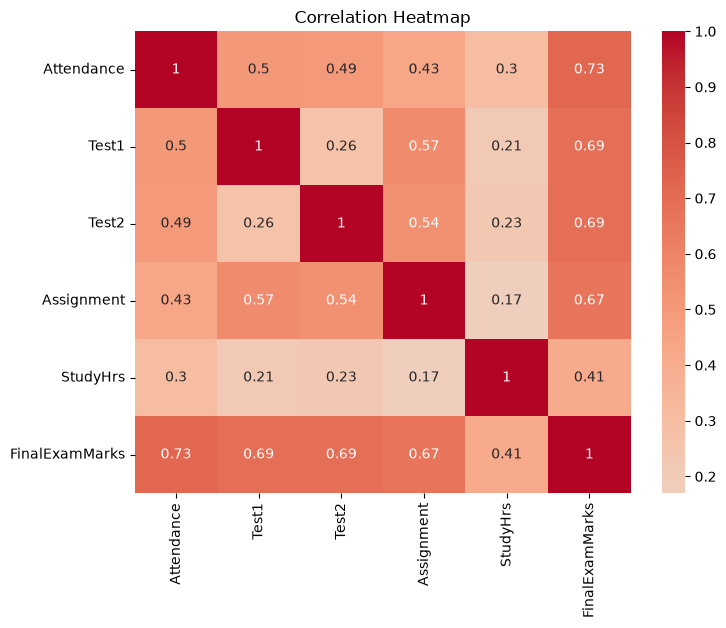

In [22]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

**Data preprocessing**

In [23]:
# separate features and target  
X = df.drop(columns=[target_column])
y = df[target_column]

In [24]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1597, 5)
Test shape: (400, 5)


In [25]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
preprocess = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Attendance','Test1','Test2','Assignment','StudyHrs']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples

Evaluation of baseline model

In [26]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [27]:
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
MAE : 3.645
RMSE: 4.627
R2  : 0.837


In [28]:
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
MAE : 3.484
RMSE: 4.389
R2  : 0.839


**Model Selection & Optimization**

In [29]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor()
}

In [30]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [31]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean()        
    })


# sort based on lowest mae value
cv_results = pd.DataFrame(rows).sort_values("cv_mae")
print("=== CV Model Comparison ===")
cv_results

=== CV Model Comparison ===


,model,cv_mae,cv_rmse,cv_r2
1,Ridge,3.655286,4.638622,0.834251
0,LinearRegression,3.655364,4.638654,0.834248
2,Lasso,3.835997,4.860232,0.818042
4,RandomForest,4.143112,5.237317,0.788478
5,XGBoost,4.550246,5.727882,0.747135
3,DecisionTree,5.721087,7.163302,0.604146


In [32]:
best_row = cv_results.sort_values("cv_mae").iloc[0]

best_model_name = best_row["model"]
best_mae = best_row["cv_mae"]

print("Best model based on CV MAE:")
print("Model :", best_model_name)
print("CV MAE:", best_mae)

Best model based on CV MAE:
Model : Ridge
CV MAE: 3.6552857525600877


**Hyperparameter Tuning**

In [33]:
ridge_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", Ridge())
    ]
)

# Hyperparameter combinations
param_grid_ridge = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters: {'model__alpha': 10}
Best CV MAE: 3.654694080855021


**Retraining with best params**

In [34]:
ridge_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", Ridge(
            alpha=100
        ))
    ]
)
ridge_best.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Attendance','Test1','Test2','Assignment','StudyHrs']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples

In [35]:
train_final_pred = ridge_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Train Performance ===")
print(f"MAE : {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Train Performance ===
MAE : 3.654
RMSE: 4.639
R2  : 0.836


In [36]:
test_final_pred = ridge_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned RF) Test Performance ===")
print(f"MAE : {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned RF) Test Performance ===
MAE : 3.509
RMSE: 4.392
R2  : 0.839


**Building a predictive system**

In [37]:
df.head()

,Attendance,Test1,Test2,Assignment,StudyHrs,FinalExamMarks
0,84,30,36,7,3,72
1,91,24,38,6,3,56
2,73,29,26,7,3,56
3,80,36,35,7,3,74
4,84,31,37,8,3,66


In [39]:
def predict_marks(
    model,
    attendance: int,
    test1: int,
    test2: int,
    assignment: int,
    hrs: int
) -> float:

    new_row = pd.DataFrame([{
        "Attendance": attendance,
        "Test1": test1,
        "Test2": test2,
        "Assignment": assignment,
        "StudyHrs": hrs
    }])
    marks = model.predict(new_row)[0] 
    if marks < 0:
        marks = 0
    elif marks > 100:
        marks = 100   
    return float(marks)


pred = predict_marks(
    ridge_best,
    attendance=100,
    test1 = 40,
    test2 = 40,
    assignment=10,
    hrs=8
)
print("Predicted Exam Marks:", round(pred, 2))

Predicted Exam Marks: 100.0


In [40]:
dump(ridge_best, "D:/My Learning/ML projects/Student-performance-prediction/backend/model.joblib")

['D:/My Learning/ML projects/Student-performance-prediction/backend/model.joblib']